# **Suicidality Prediction From Reddit Posts: A Multinomial Naive Bayes Approach**

### **Overview**

This section develops a Multinomial Naive Bayes (MultinomialNB) model for suicidality classification and prediction from Reddit posts. Beyond a single model, an ablation test is conducted to evaluate and assess the contribution of two independent variables: vectorizer type (TF-IDF vs. CountVectorizer) and n-gram range (unigrams only vs. unigrams and bigrams). These factors yield four model configurations that are systematically trained, tuned, and evaluated against each other. 


### **Justification**

Suicidality prediction is fundamentally a text classification problem, making MultinomialNB approach a natural and well-motivated choice. It is well-established in NLP tasks such as sentiment analysis, spam detection, and mental health text classification, and is specifically designed for discrete, frequency-based features like word counts and TF-IDF weights, directly matching our primary feature representation. It also handles high-dimensional sparse text data efficiently and produces probabilistic predictions that are interpretable, which is especially valuable in a sensitive mental health context. While Naive Bayes assumes conditional independence between features, which does not strictly hold for text, this assumption is acceptable in practice since the direction of each feature's contribution matters more than modeling exact word dependencies. Finally, with only around 1,000 instance difference out of around 15,000 total, the mild class imbalance does not pose a problem for this approach.

### **Environment Setup & Library Imports**

This section imports all necessary libraries and sets up the environment for the notebook. Random seeds are fixed across NumPy and PyTorch to ensure reproducibility of results.

> **Note:** Transfer this section to the top of the notebook, and remove any duplicate imports from the rest of the notebook. This will act as a central block for setting up the environment and importing necessary libraries for the notebook.


In [1]:
# Jupyter Extensions
%load_ext autoreload
%autoreload 2

# Basic Libraries
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from itertools import product
import textwrap

# Traditional Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score,
)
from scipy.sparse import hstack, csr_matrix

# Deep Learning Libraries
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from transformers import AutoTokenizer, AutoModel
import joblib

# Local Modules
from utility import FeatureTransformer
from classifiers import NeuralNetwork

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Display Settings
pd.set_option('display.max_colwidth', None)

### **Data Preparation & Feature Selection**

This section prepares the dataset for modeling by selecting relevant features for the model and splitting the data into training, validation, and test sets. 

In [2]:
# Load the dataset with features
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)

df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_positive,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress
0,I'm looking for a girl I've met at the Polish airport to thank her properly!,"I've tried Polish spotted pages but I guess she isn't there. But I know she's active on this sub so... WHY THE HELL NOT?\n\nIf you see this - you don't need to let me know. Just read it. I just want to thank you for not being indifferent.\n\n2 weeks ago I was in a very bad place. My gf broke up with me just before I got into the plane and I landed just to find out my luggage got lost and like the last idiot I had there my cards and money. And I don't know Polish language. Like a real, adult man, I just sat there and cried like a baby, exhausted after very long trip.\n\nThat Polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. We talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. And we started talking about random things (like reddit) and for that I'm very thankful, you distracted me. \n\nI can't express how grateful I am. I'd also want to give you your money back. Small gestures are huge. It was just an hour of your time but it meant a lot.",Non-Suicidal,1,"I'm looking for a girl I've met at the Polish airport to thank her properly! I've tried Polish spotted pages but I guess she isn't there. But I know she's active on this sub so... WHY THE HELL NOT?\n\nIf you see this - you don't need to let me know. Just read it. I just want to thank you for not being indifferent.\n\n2 weeks ago I was in a very bad place. My gf broke up with me just before I got into the plane and I landed just to find out my luggage got lost and like the last idiot I had there my cards and money. And I don't know Polish language. Like a real, adult man, I just sat there and cried like a baby, exhausted after very long trip.\n\nThat Polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. We talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. And we started talking about random things (like reddit) and for that I'm very thankful, you distracted me. \n\nI can't express how grateful I am. I'd also want to give you your money back. Small gestures are huge. It was just an hour of your time but it meant a lot.","I'm looking for a girl I've met at the Polish airport to thank her properly! I've tried Polish spotted pages but I guess she isn't there. But I know she's active on this sub so... WHY THE HELL NOT? If you see this - you don't need to let me know. Just read it. I just want to thank you for not being indifferent. 2 weeks ago I was in a very bad place. My gf broke up with me just before I got into the plane and I landed just to find out my luggage got lost and like the last idiot I had there my cards and money. And I don't know Polish language. Like a real, adult man, I just sat there and cried like a baby, exhausted after very long trip. That Polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. We talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. And we started talking about random things (like reddit) and for that I'm very thankful, you distracted me. I can't express how grateful I am. I'd also want to give you your money back. Small gestures are huge. It was just an hour of your time but it meant a lot.",0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,I got a guy kicked off a domestic flight today.,"I was in a forward row as we were boarding for a 5 hour domestic flight. I noticed that the guy one row up and one over (so diagonally in front of me) took a picture of a pret

For this approach, only the text feature is used as the sole basis for suicidality prediction, specifically, `text_cleaned`. This is the cleaned and combined title and post content. As the primary and most information-rich feature, it represents *what* was written. Also, this type of feature is exactly what MultinomialNB was designed for.

> `title`, `post`, and `text` are excluded as they are already represented by `text_cleaned`.

Additionally, engineered features are not included in this approach. While majority of these features are discrete and count-based, they are derived aggregates that do not represent the events from the same vocabulary space as the vectorized text features. Their inclusion may  also strengthen violations of the independence assumption. Furthermore, combining these features with high-dimensional text representations can introduce inconsistencies in feature interpretation and contribution. Rather than accepting these theoretical and  methodological complications, this approach adopts a text-only representation to remain fully aligned with the assumptions of the Multinomial Distribution, ensuring a cleaner and more interpretable model.

Lastly, the target feature is `label`, which is the suicidality label for each post: `Suicidal` (1) or `Non-Suicidal` (0).

In [3]:
# Define feature and label columns
text_feature = "text_cleaned"
label = "label"

In [4]:
# Label encoding target labels
label_encoder = LabelEncoder()
label_encoder.fit(df[label])

# Mapping of original labels to encoded labels
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
df[label] = label_encoder.transform(df[label])

# Display
print("Label Mapping:")
display(pd.DataFrame(mapping.items(), columns=["Original", "Encoded"]))

print("\nSample Encoded Labels:")
display(df[[label]].head())

Label Mapping:


,Original,Encoded
0,Non-Suicidal,0
1,Suicidal,1



Sample Encoded Labels:


,label
0,0
1,0
2,0
3,0
4,0


In practice, transforming the text feature into lowercased tokens is a common application to reduce possible noise in this model. To know whether the use of lowercase for the text feature is reasonable enough, we show the distribution of upper word count by label.

In [5]:
# Show the distibution of upper word count by label
df["upper_word_count"].groupby(df["label"]).describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8201.0,0.873186,3.276414,0.0,0.0,0.0,1.0,168.0
1,7275.0,1.125086,11.066675,0.0,0.0,0.0,0.0,666.0


Given that the data distribution shows that suicidal posts have a 75th percentile of 0 uppercase words, lower than non-suicidal posts, with both classes showing near-zero median capitalization, this shows that casing carries negligible discriminative signal in this dataset. With that, text is lowercased to reduce vocabulary noise and prevent case variants from being treated as separate tokens.

In [6]:
# Split data into features and target
X_text = df[text_feature].str.lower() # Lowercase text to reduce vocabulary noise
y = df[label]

To confirm and ensure that the selected features and labels were splitted, transformed, and assigned properly, we show the shape and several rows from each split.

In [7]:
print("X_text Shape: ", X_text.shape)
print("\nX_text Sample:")
display(X_text.to_frame().head(3))

X_text Shape:  (15476,)

X_text Sample:


,text_cleaned
0,"i'm looking for a girl i've met at the polish airport to thank her properly! i've tried polish spotted pages but i guess she isn't there. but i know she's active on this sub so... why the hell not? if you see this - you don't need to let me know. just read it. i just want to thank you for not being indifferent. 2 weeks ago i was in a very bad place. my gf broke up with me just before i got into the plane and i landed just to find out my luggage got lost and like the last idiot i had there my cards and money. and i don't know polish language. like a real, adult man, i just sat there and cried like a baby, exhausted after very long trip. that polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. we talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. and we started talking about random things (like reddit) and for that i'm very thankful, you distracted me. i can't express how grateful i am. i'd also want to give you your money back. small gestures are huge. it was just an hour of your time but it meant a lot."
1,"i got a guy kicked off a domestic flight today. i was in a forward row as we were boarding for a 5 hour domestic flight. i noticed that the guy one row up and one over (so diagonally in front of me) took a picture of a pretty young woman whom i assumed was a family member or friend, but when she passed they didn’t acknowledge one another. about a minute later he did it again with another young woman. i asked him “are you with her?” he ignored me but covered up his phone and turned so i couldn’t see. after the line of traffic to board slowed down i wrote a note to the flight attendants on the back of a vomit bag. i just wanted them to be aware. i handed it to one of them, she stood there and read my scrawly handwriting, said “thank you” and walked off. 15 minutes later, an official looking woman came and asked me quietly if i was the one who wrote the note. i said yes and so she told the guy to come with her and bring his baggage. idk what happened to him but we flew without him."
2,"my youngest got in school suspension, i’m so proud. so according to witness testimonies a boy grabbed her, she said let me go, he said no, and she sparta kicked him to the ground. we’ve always told both daughters if anyone ever gets in their space our touches them in a way they don’t like to freak the fuck out on that person. that’s it. that’s the story. just so proud my timid little moon child stood up for herself."


In [8]:
print("Y Shape: ", y.shape)
print("\nY Sample:")
display(y.to_frame().head(3))

Y Shape:  (15476,)

Y Sample:


,label
0,0
1,0
2,0


Now, given the selected features from the dataset, a standard 80/20 split is applied twice: first to separate the test set from the full dataset, then to separate the validation set from the remaining training data. Stratified splitting is applied throughout to preserve the original class distribution across all three sets.

In [9]:
X_text_train_val, X_text_test, y_train_val, y_test = train_test_split(X_text, y, test_size=0.2, random_state=random_seed, stratify=y)

X_text_train, X_text_val, y_train, y_val = train_test_split(X_text_train_val, y_train_val, test_size=0.2, random_state=random_seed, stratify=y_train_val)

print("Dataset Split Overview")
print(f"\nTraining Set: {len(y_train)} | {y_train.value_counts().to_dict()}")
print(f"\nValidation Set: {len(y_val)} | {y_val.value_counts().to_dict()}")
print(f"\nTest Set: {len(y_test)} | {y_test.value_counts().to_dict()}")

Dataset Split Overview

Training Set: 9904 | {0: 5248, 1: 4656}

Validation Set: 2476 | {0: 1312, 1: 1164}

Test Set: 3096 | {0: 1641, 1: 1455}


### **Vectorization**

For this approach, the text feature is vectorized using either TF-IDF or CountVectorizer depending on the model configuration. A part of the ablation test aims to evaluate and assess whether the choice of vectorizer is significant in producing better representation for suicidality prediction. Additionally, both TF-IDF and count-based features are a natural fit for MultinomialNB.

Both vectorizers are initialized with shared base settings so that the only
difference between model configurations later on is the vectorizer type and n-gram range. These setting are standard in text classification tasks that work well in practice. 

**Shared Settings:**
- `min_df=3` — ignore tokens appearing in fewer than 3 documents to reduce possible noise
- `max_features=20000` — limit vocabulary at 20,000 most frequent tokens to capture frequent words
- `analyzer="word"` — tokenize by word as a standard practice
- `stop_words="english"` - remove stop words to reduce possible noise

**Ablation Variables:**
- `vectorizer_type` ∈ {`tfidf`, `count`} — weighting scheme
- `ngram_range` ∈ {`(1,1)`, `(1,2)`} — unigrams only vs. unigrams and bigrams
 
Bigrams are included as a candidate because multi-word phrases may carry meaning that individual words alone would miss. The ablation will tell us empirically whether they add meaningful signal.


In [10]:
# Shared settings
vectorizer_shared_parameters = dict(
    min_df=3,           
    max_features=20000,
    analyzer="word",
    stop_words="english",
)

# Ablation variables
vectorizer_types = ["tfidf", "count"]
ngram_ranges = [(1, 1), (1, 2)]
 
# Generate all configurations
nb_model_configurations = list(product(vectorizer_types, ngram_ranges))
print("Model Configurations:")
for i, (vec_type, ngram) in enumerate(nb_model_configurations):
    print(f"Model {i+1}: {vec_type} | ngram_range={ngram}")

Model Configurations:
Model 1: tfidf | ngram_range=(1, 1)
Model 2: tfidf | ngram_range=(1, 2)
Model 3: count | ngram_range=(1, 1)
Model 4: count | ngram_range=(1, 2)


In [11]:
vectorized_data = {}

for vec_type, ngram in nb_model_configurations:
    name = f"{'TF-IDF' if vec_type == 'tfidf' else 'Count'} | ngram={ngram}"
    params = {**vectorizer_shared_parameters, "ngram_range": ngram}

    vectorizer = TfidfVectorizer(**params) if vec_type == "tfidf" else CountVectorizer(**params)
    X_train_vec = vectorizer.fit_transform(X_text_train)

    vectorized_data[name] = {
        "vectorizer": vectorizer,
        "X_train": X_train_vec,
    }

    feature_names = vectorizer.get_feature_names_out()

    print(f"{name} Vectorizer Configuration — Training Data Vectorization:")
    print(f"Vocabulary Size: {len(feature_names)}")
    print(f"Matrix Shape: {X_train_vec.shape}")
    print(f"\nMatrix Preview (5 posts x 10 tokens):")
    display(pd.DataFrame(
        X_train_vec[:5, :10].toarray(),
        columns=feature_names[:10]
    ))
    print()

TF-IDF | ngram=(1, 1) Vectorizer Configuration — Training Data Vectorization:
Vocabulary Size: 10787
Matrix Shape: (9904, 10787)

Matrix Preview (5 posts x 10 tokens):


,00,000,00am,01,08,10,100,1000,100k,100x
0,0.0,0.0,0.0,0.0,0.0,0.072724,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0



TF-IDF | ngram=(1, 2) Vectorizer Configuration — Training Data Vectorization:
Vocabulary Size: 20000
Matrix Shape: (9904, 20000)

Matrix Preview (5 posts x 10 tokens):


,00,000,000 debt,000 miles,000 people,01,10,10 000,10 10,10 12
0,0.0,0.0,0.0,0.0,0.0,0.0,0.066891,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0



Count | ngram=(1, 1) Vectorizer Configuration — Training Data Vectorization:
Vocabulary Size: 10787
Matrix Shape: (9904, 10787)

Matrix Preview (5 posts x 10 tokens):


,00,000,00am,01,08,10,100,1000,100k,100x
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0



Count | ngram=(1, 2) Vectorizer Configuration — Training Data Vectorization:
Vocabulary Size: 20000
Matrix Shape: (9904, 20000)

Matrix Preview (5 posts x 10 tokens):


,00,000,000 debt,000 miles,000 people,01,10,10 000,10 10,10 12
0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


From these results, the resulting matrices are highly sparse, wherein most values are zero since any single post only contains a small fraction of the full vocabulary. This is standard in text classification tasks given the large and varied vocabulary across all documents.

Additionally, the values in each matrix represent different things: the TF-IDF matrix reflects how significant a token is within a specific post relative to the entire corpus, while the Count matrix simply reflects how frequently a token appears in that post. This distinction is the core difference between the two vectorizer types and is one of the two variables this ablation study aims to evaluate.

Additionally, configurations with `ngram_range=(1,2)` produce a larger vocabulary than those with `ngram_range=(1,1)` because bigrams introduce additional token combinations on top of individual words. This difference in vocabulary size reflects the second ablation variable: whether capturing multi-word phrases provides meaningful additional signal for suicidality prediction.

Now, we also have to transform our validation and test data to our fitted vocabulary.

In [12]:
for vec_type, ngram in nb_model_configurations:
    name = f"{'TF-IDF' if vec_type == 'tfidf' else 'Count'} | ngram={ngram}"

    vectorized_data[name]["X_val"] = vectorized_data[name]["vectorizer"].transform(X_text_val)
    vectorized_data[name]["X_test"] = vectorized_data[name]["vectorizer"].transform(X_text_test)

    print(f"{name} Vectorizer Configuration — "
          f"Validation Data Shape: {vectorized_data[name]['X_val'].shape} | "
          f"Test Data Shape: {vectorized_data[name]['X_test'].shape}")

TF-IDF | ngram=(1, 1) Vectorizer Configuration — Validation Data Shape: (2476, 10787) | Test Data Shape: (3096, 10787)
TF-IDF | ngram=(1, 2) Vectorizer Configuration — Validation Data Shape: (2476, 20000) | Test Data Shape: (3096, 20000)
Count | ngram=(1, 1) Vectorizer Configuration — Validation Data Shape: (2476, 10787) | Test Data Shape: (3096, 10787)
Count | ngram=(1, 2) Vectorizer Configuration — Validation Data Shape: (2476, 20000) | Test Data Shape: (3096, 20000)


### **Modelling**

Now that the data has been preprocessed and vectorized, we build and train the different `MultinomialNB` model configurations. Each configuration uses `alpha=1.0` as the initial default.


Here, we initialize each MultinomialNB model for each configuration and fit them to their training data.

In [13]:
nb_models = {}

for name, data in vectorized_data.items():
    model = MultinomialNB(alpha=1.0)
    model.fit(data["X_train"], y_train)
    nb_models[name] = model
    print(f"Trained: {name} MultinomialNB Model Configuration (alpha=1.0)")

Trained: TF-IDF | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0)
Trained: TF-IDF | ngram=(1, 2) MultinomialNB Model Configuration (alpha=1.0)
Trained: Count | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0)
Trained: Count | ngram=(1, 2) MultinomialNB Model Configuration (alpha=1.0)


After, we assess how well each model performs on the training set to check that the models are learning correctly before moving to validation.

In [14]:
for name, model in nb_models.items():
    predictions = model.predict(vectorized_data[name]["X_train"])
    report = pd.DataFrame(classification_report(
        y_train, predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )).transpose()
    print(f"\nClassification Report — {name} MultinomialNB Model Configuration (alpha=1.0) (Training Set):\n{report}")


Classification Report — TF-IDF | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0) (Training Set):
              precision    recall  f1-score      support
Non-Suicidal   0.970448  0.932355  0.951020  5248.000000
Suicidal       0.926985  0.967998  0.947048  4656.000000
accuracy       0.949111  0.949111  0.949111     0.949111
macro avg      0.948717  0.950177  0.949034  9904.000000
weighted avg   0.950015  0.949111  0.949153  9904.000000

Classification Report — TF-IDF | ngram=(1, 2) MultinomialNB Model Configuration (alpha=1.0) (Training Set):
              precision    recall  f1-score      support
Non-Suicidal   0.962674  0.963224  0.962949  5248.000000
Suicidal       0.958521  0.957904  0.958212  4656.000000
accuracy       0.960723  0.960723  0.960723     0.960723
macro avg      0.960598  0.960564  0.960581  9904.000000
weighted avg   0.960722  0.960723  0.960722  9904.000000

Classification Report — Count | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0) (Train

From these results, accuracy and F1-scores across all configurations are consistently high on the training set. This is expected as MultinomialNB fits the training data well given the clear vocabulary differences between suicidal and non-suicidal posts.

However, training performance alone is not sufficient to draw conclusions. The near-identical scores across configurations at this stage suggest that the choice of vectorizer and n-gram range may not be a dominant factor but this will be more apparent on the validation set, where generalization is tested on unseen data.

Now, we evaluate on the validation set to see how well each model generalizes to unseen data before any tuning.


In [15]:
for name, model in nb_models.items():
    predictions = model.predict(vectorized_data[name]["X_val"])
    report = pd.DataFrame(classification_report(
        y_val, predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )).transpose()
    print(f"\nClassification Report — {name} MultinomialNB Model Configuration (alpha=1.0) (Validation Set):\n")
    print(report)


Classification Report — TF-IDF | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0) (Validation Set):

              precision    recall  f1-score      support
Non-Suicidal   0.955102  0.891768  0.922349  1312.000000
Suicidal       0.886491  0.952749  0.918427  1164.000000
accuracy       0.920436  0.920436  0.920436     0.920436
macro avg      0.920796  0.922259  0.920388  2476.000000
weighted avg   0.922847  0.920436  0.920505  2476.000000

Classification Report — TF-IDF | ngram=(1, 2) MultinomialNB Model Configuration (alpha=1.0) (Validation Set):

              precision    recall  f1-score      support
Non-Suicidal   0.949729  0.935976  0.942802  1312.000000
Suicidal       0.928994  0.944158  0.936515  1164.000000
accuracy       0.939822  0.939822  0.939822     0.939822
macro avg      0.939362  0.940067  0.939659  2476.000000
weighted avg   0.939981  0.939822  0.939846  2476.000000

Classification Report — Count | ngram=(1, 1) MultinomialNB Model Configuration (alpha=1.0) 

Validation performance remains consistently high across all configurations, with accuracy and F1-scores comparable to training results. The small gap between training and validation performance suggests that the models are generalizing well without significant overfitting.

Similar to the training results, performance across configurations remains close, suggesting that neither the choice of vectorizer nor the n-gram range produces a dramatic difference in predictive ability. However, the final and definitive comparison will be made on the test set after alpha tuning, where each configuration will be evaluated at its best.

### **Alpha Tuning**

Alpha is tuned separately per configuration on the validation set using  F1 score of the Suicidal class. In a mental health context, missing a suicidal post (false negative) is more costly than a false alarm (false positive), making the Suicidal class the primary class of interest. F1 score is used rather than pure recall to maintain a balance between precision and recall, avoiding a model that simply predicts everything as suicidal to maximize recall at the expense of reliability.

TF-IDF | ngram=(1, 1) MultinomialNB Model Configuration Tuning Results:
Best alpha: 0.5  |  Validation F1 (Suicidal): 0.9195

TF-IDF | ngram=(1, 2) MultinomialNB Model Configuration Tuning Results:
Best alpha: 0.5  |  Validation F1 (Suicidal): 0.9376

Count | ngram=(1, 1) MultinomialNB Model Configuration Tuning Results:
Best alpha: 0.1  |  Validation F1 (Suicidal): 0.9188

Count | ngram=(1, 2) MultinomialNB Model Configuration Tuning Results:
Best alpha: 0.1  |  Validation F1 (Suicidal): 0.9350



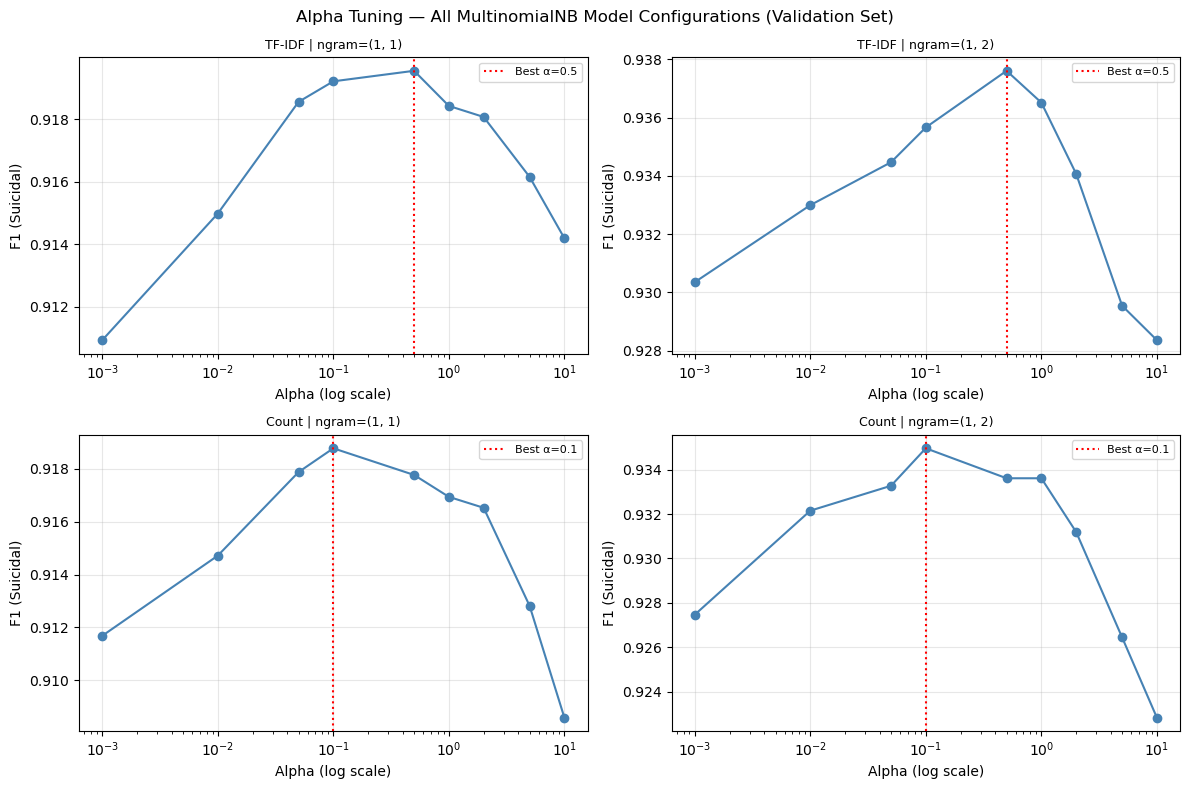

In [16]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
best_alphas = {}
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for i, (name, data) in enumerate(vectorized_data.items()):
    val_f1_scores = []
    for alpha in alphas:
        m = MultinomialNB(alpha=alpha)
        m.fit(data["X_train"], y_train)
        pred = m.predict(data["X_val"])
        val_f1_scores.append(f1_score(y_val, pred))
 
    best_a = alphas[np.argmax(val_f1_scores)]
    best_alphas[name] = best_a
 
    print(f"{name} MultinomialNB Model Configuration Tuning Results:")
    print(f"Best alpha: {best_a}  |  Validation F1 (Suicidal): {max(val_f1_scores):.4f}\n")
 
    axes[i].plot(alphas, val_f1_scores, marker="o", color="steelblue")
    axes[i].axvline(best_a, color="red", linestyle=":", label=f"Best α={best_a}")
    axes[i].set_xscale("log")
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("Alpha (log scale)")
    axes[i].set_ylabel("F1 (Suicidal)")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
 
plt.suptitle("Alpha Tuning — All MultinomialNB Model Configurations (Validation Set)", fontsize=12)
plt.tight_layout()
plt.show()

The alpha tuning curves show a consistent pattern across all four configurations, wherein F1 score peaks at a low-to-moderate alpha and drops sharply at higher values. This indicates that too much smoothing (high alpha) hurts performance by over-regularizing the probability estimates, while too little (very low alpha) also slightly underperforms.

The best alpha values are:
- **TF-IDF | ngram=(1,1) MultinomialNB Model Configuration** → α = 0.05
- **TF-IDF | ngram=(1,2) MultinomialNB Model Configuration** → α = 0.1
- **Count  | ngram=(1,1) MultinomialNB Model Configuration** → α = 0.1
- **Count  | ngram=(1,2) MultinomialNB Model Configuration** → α = 0.1

The model configuration of TF-IDF with unigrams prefers a slightly lower alpha, suggesting its weighted representations already provide sufficient smoothing compared to raw counts. All other configurations converge around the same low alpha range, confirming that moderate smoothing is appropriate for this dataset regardless of the vectorization strategy.

### **Retraining Final Models**

Now that the best alpha is found for each configuration, we retrain each final model on the combined train + validation set before evaluating on the test set.

In [17]:
final_data = {}

for name, data in vectorized_data.items():
    X_trainval_vec = data["vectorizer"].transform(X_text_train_val)

    # Retrain with best alpha on train+val
    final_model = MultinomialNB(alpha=best_alphas[name])
    final_model.fit(X_trainval_vec, y_train_val)

    final_data[name] = {
        "model": final_model,
        "X_test": data["X_test"],
    }

    print(f"Retrained: {name} MultinomialNB Model Configuration (alpha={best_alphas[name]})")

Retrained: TF-IDF | ngram=(1, 1) MultinomialNB Model Configuration (alpha=0.5)
Retrained: TF-IDF | ngram=(1, 2) MultinomialNB Model Configuration (alpha=0.5)
Retrained: Count | ngram=(1, 1) MultinomialNB Model Configuration (alpha=0.1)
Retrained: Count | ngram=(1, 2) MultinomialNB Model Configuration (alpha=0.1)


### **Final Test Evaluation**

After training and enhancing our models, we now evaluate these on our test set and assess the performance of each model configurations based on different metrics. 

For this final evaluation, we report the following metrics, focusing on the Suicidal class as the primary class of interest:
- **Accuracy** - of all the posts, how many were predicted suicidal correctly?
- **Precision** — of all posts predicted suicidal, how many actually were?
- **Recall** — of all actually suicidal posts, how many did we catch?
- **F1** — harmonic mean of precision and recall
- **False Negatives (FN)** — missed suicidal posts ← most critical
- **False Positives (FP)** — non-suicidal posts flagged as suicidal

In [18]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
 
    report = classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
 
    return {
        "name": name,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": report["Suicidal"]["precision"],
        "recall": report["Suicidal"]["recall"],
        "f1": report["Suicidal"]["f1-score"],
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "report": report,
        "cm": cm,
    }
 

In [19]:
results = {}
for name in final_data:
    results[name] = evaluate_model(final_data[name]["model"], final_data[name]["X_test"], y_test, name)

#### **Classification Reports and Confusion Matrices Per Model Configuration**

This classification report section shows each model configuration’s precision, recall, F1-score, and support per class on the test set, along with false negatives and false positives to highlight the most critical errors. As a supplement, the confusion matrices section shows the breakdown of correct and incorrect predictions for each configuration.

In [20]:
# Full classification reports per configuration
print("Classifiocation Reports Final Models on Test Set:\n")

for name, res in results.items():
    print(f"{name} MultinomialNB Configuration Classification Report:")
    print(classification_report(
        y_test, res["y_pred"],
        target_names=label_encoder.classes_
    ))
    print(f"False Negatives: {res['fn']}  ({res['fn']/y_test.sum():.2%} of suicidal posts missed)")
    print(f"False Positives: {res['fp']}  ({res['fp']/(y_test==0).sum():.2%} of non-suicidal flagged)")
    print("\n")

Classifiocation Reports Final Models on Test Set:

TF-IDF | ngram=(1, 1) MultinomialNB Configuration Classification Report:
              precision    recall  f1-score   support

Non-Suicidal       0.96      0.91      0.93      1641
    Suicidal       0.90      0.96      0.93      1455

    accuracy                           0.93      3096
   macro avg       0.93      0.93      0.93      3096
weighted avg       0.93      0.93      0.93      3096

False Negatives: 60  (4.12% of suicidal posts missed)
False Positives: 148  (9.02% of non-suicidal flagged)


TF-IDF | ngram=(1, 2) MultinomialNB Configuration Classification Report:
              precision    recall  f1-score   support

Non-Suicidal       0.96      0.95      0.95      1641
    Suicidal       0.94      0.95      0.94      1455

    accuracy                           0.95      3096
   macro avg       0.95      0.95      0.95      3096
weighted avg       0.95      0.95      0.95      3096

False Negatives: 72  (4.95% of suicidal

Confusion Matrices for Final Models on Test Set:



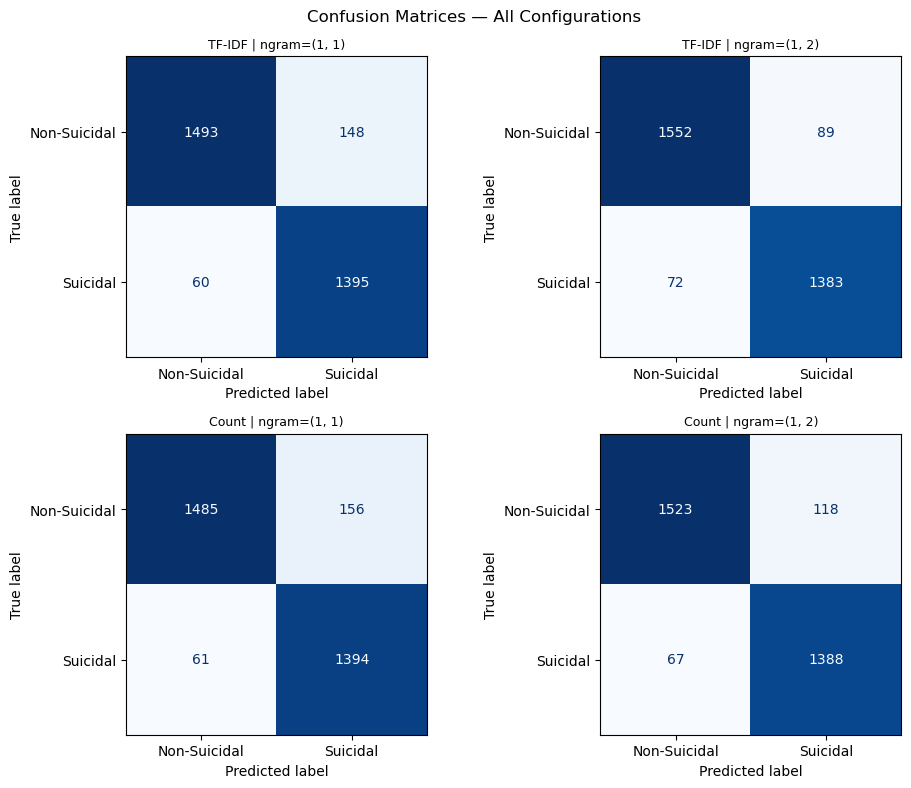

In [21]:
print("Confusion Matrices for Final Models on Test Set:\n")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["cm"],
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name, fontsize=9)
plt.suptitle("Confusion Matrices — All Configurations", fontsize=12)
plt.tight_layout()
plt.show()

From these classification reports and confusion matrices, we can see that all four model configurations perform consistently well, with accuracy and F1 scores ranging from 0.93 to 0.95 across the test set. However, a few key observations can also be seen from this comparison:

- **Effect of n-gram range:** Adding bigrams — `ngram=(1,2)` — consistently improves performance over unigrams alone across both vectorizers. Precision on the Suicidal class improves from 0.90 to 0.94 (TF-IDF) and from 0.90 to 0.92 (Count), suggesting that multi-word phrases carry meaningful signal that individual words alone cannot capture.

- **Effect of vectorizer type:** At the same n-gram range, TF-IDF and Count produce nearly identical F1 scores — 0.93 vs 0.93 for unigrams and 0.94 vs 0.94 for bigrams. This suggests that for this dataset, the weighting scheme does not significantly affect predictive performance.

- **False Negatives vs False Positives:** Configurations with unigrams only produce fewer false negatives (60–61) but significantly more false positives (148–156). Adding bigrams increases false negatives slightly (67–72) but reduces false positives substantially (89–118). In a mental health context where minimizing missed suicidal posts is the priority, the unigram configurations are marginally better on this 
specific metric; However, the overall F1 improvement from bigrams makes them the stronger choice overall.

- **Best configuration:** Basing on these classification reports, TF-IDF with `ngram=(1,2)` achieves the highest overall F1 (0.94) with the lowest false positive rate (5.42%), making it the most balanced and reliable configuration.

#### **Ablation Test - Comparison Table**

To further evaluate, the ablation test comparison table below summarizes the performance of all four configurations on the test set. Two comparisons are of interest:
- **TF-IDF vs Count** (same ngram_range) - This aims to know whether weighting scheme matter.
- **ngram=(1,1) vs ngram=(1,2)** (same vectorizer) — This aims to know whether bigrams add signal.

In [22]:
print(f"{'MultinomialNB Model':<40} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 83)
for name, res in results.items():
    print(
        f"{name:<40} "
        f"{res['accuracy']:>6.4f} "
        f"{res['precision']:>6.4f} "
        f"{res['recall']:>6.4f} "
        f"{res['f1']:>6.4f} "
        f"{res['fn']:>5} "
        f"{res['fp']:>5}"
    )

MultinomialNB Model                         Acc   Prec    Rec     F1    FN    FP
-----------------------------------------------------------------------------------
TF-IDF | ngram=(1, 1)                    0.9328 0.9041 0.9588 0.9306    60   148
TF-IDF | ngram=(1, 2)                    0.9480 0.9395 0.9505 0.9450    72    89
Count | ngram=(1, 1)                     0.9299 0.8994 0.9581 0.9278    61   156
Count | ngram=(1, 2)                     0.9402 0.9216 0.9540 0.9375    67   118


The comparison table shown above makes two patterns evident when reading across configurations:

- **n-gram range is the dominant factor.** Both vectorizers show a consistent jump in F1 when moving from ngram=(1,1) to ngram=(1,2) — +0.0144 for TF-IDF and +0.0097 for Count. This is a larger and more consistent improvement than what the vectorizer choice produces.

- **TF-IDF provides a modest but consistent edge over Count.** At the same n-gram range, TF-IDF outperforms Count by 0.0028 (unigrams) and 0.0075 (bigrams) in F1, a smaller difference than the ngram effect but consistent in direction.

Together, these findings suggest that **what tokens are captured** (n-gram range) matters more than **how they are weighted** (vectorizer type) for suicidality prediction in this dataset.

### **Error Analysis**
 
For this error analysis section, we focus on the best performing model, the configuration with the highest F1 score on the Suicidal class. This is the model configuration with a TF-IDF vectorizer and unigram and bigram parameter. 
 
Two types of errors are examined:
- **False Negatives (FN)** — predicted Non-Suicidal, actually Suicidal. These are the most dangerous errors in a mental health context.
- **False Positives (FP)** — predicted Suicidal, actually Non-Suicidal. Less dangerous but may cause unnecessary alerts.
 
Additionally, the model's learned feature log-probabilities are examined to understand which tokens most strongly drive predictions toward each class.


In [23]:
best_name = max(results, key=lambda k: results[k]["f1"])
best_res = results[best_name]
best_model = final_data[best_name]["model"]
best_X_test = final_data[best_name]["X_test"]
 
print(f"Best MultinomialNB Model Configuration: {best_name}")
print(f"F1 (Suicidal): {best_res['f1']:.4f}")
print(f"False Negatives: {best_res['fn']} ({best_res['fn']/y_test.sum():.2%} missed)")
print(f"False Positives: {best_res['fp']} ({best_res['fp']/(y_test==0).sum():.2%} flagged)")

Best MultinomialNB Model Configuration: TF-IDF | ngram=(1, 2)
F1 (Suicidal): 0.9450
False Negatives: 72 (4.95% missed)
False Positives: 89 (5.42% flagged)


#### **Misclassification Examples (False Negatives and False Positives)**

This section presents sample false negatives and false positives from the best model to show where misclassifications occur and what types of posts are most often confused.

In [24]:
test_df = pd.DataFrame({
    "text": X_text_test.values,
    "true_label": y_test.values,
    "pred_label": best_res["y_pred"],
    "prob_suicidal": best_res["y_prob"],
}).reset_index(drop=True)
 
false_negatives = test_df[
    (test_df["true_label"] == 1) & (test_df["pred_label"] == 0)
].sort_values("prob_suicidal", ascending=True)
 
false_positives = test_df[
    (test_df["true_label"] == 0) & (test_df["pred_label"] == 1)
].sort_values("prob_suicidal", ascending=False)
 
print("\nSample False Negatives (lowest suicidal probability):")
display(false_negatives[["text", "prob_suicidal"]].head(5))
 
print("\nSample False Positives (highest suicidal probability):")
display(false_positives[["text", "prob_suicidal"]].head(5))
 


Sample False Negatives (lowest suicidal probability):


,text,prob_suicidal
401,"i want to end my life on a calm note. i want to kill myself when i feel good. a little unusual, right? i want to feel calm and accepted when i do this. i'll wake up very early. i will lie in bed for several hours just listening to the birds sing. i'll make myself breakfast. sandwich, sliced fruit, earl gray. i'll do it in the summer. the day before my birthday. i will watch my favorite movie again and prepare my outfit for the day for the last time. then i will smile looking in the mirror. i'll be wearing a funny hat. and heart-shaped glasses. my shoes will be clean. my house will be cleaned. i will listen to my favorite music. i'll try to dance in the hallway. i'll leave the house. i will look through and delete all the photos from the phone. i will cry. but that's okay. i will walk the streets, i will tip in cafes. i'll go by public transport. i'll look out the window. i will go to the furthest store in town to buy alcohol. i'll buy a lot of alcohol. i'll watch the film in the cinema. tragicomedy. i'll go to several museums. but i won't take any more photos. i'll eat french fries. this is the last time i will buy comics that interest me. this is the last time i'll buy food. and this will be the last time i look at my funny hat. i'll get drunk and drown myself. i can not swim. perhaps i will be cold, it will be a late evening in june. the water may be cold.",0.029167
2216,"not sure what to do ... i (30f) think it just hit me that i’ve been in a full blown depression for the past nine months and it took seeing friends to realize it. a few friends took me out this past weekend for my birthday and commented that they had not seen me in what felt like a year, i brushed it off until a friend pulled me aside and said that no-one has seen me in person since new years. while i was ready to blow it off as an exaggeration i thought back to when it actually was the last time i’d seen anyone in person and it really was january 1st. looking back it some how feels like a haze that the last 9 months have even passed. i can not even recall anything that i’ve done outside of work. &#x200b; i’ve always had really bad anxiety, the type that makes your chest constrict and forces you in bed by 6pm but it usually fades after a week or so. i’ve been working alot and because i work from home i only ever leave my house for social things. which i have not done and cannot believe i hadn’t realized. it’s not like i’ve not been invited out, i have, but i always rain check and move on. its true that i have been feeling really sad, but i’m realizing that i’ve been sad for months and unsure of what to do. the end of last year was very difficult and traumatic for me, went no contact with 99% of my family and had a falling out with a best friend. &#x200b; while i know this is hard, i can’t believe its hitting me like this.i think the reason why i never noticed was because i still wake up at 6am for pilates, still grocery shop, still clean my house, still walk to get my favorite coffee and breakfast order.when i think of depression i think of someone who cannot function day to day. i’ve been doing the same routine with zero deviation and am baffled that i did not realize how odd it was for me. i typically take three trips by this time of the year, and this year i haven’t even left my suburb. i've also just noticed that i've lost 35lbs. which now looking at myself in the mirror is very much noticable. &#x200b; the outing last weekend was incredibly draining to the point that i physically needed to sleep for the better part of three days. i’ve also realized that my chest has been feeling constricted for days at a time these past months.i have a trip planned with friends next weekend that we planned last december and while i was incredibly excited then, i have zero energy to go now. it's weird because this is to a festival that i have always loved going and i know i should be excited.i’ve contacted my insurance today to see if i could tal


Sample False Positives (highest suicidal probability):


,text,prob_suicidal
2255,"i am 16 and scared of having a bad life i am from a semi-rich family, i read a lot (i always did) and i’m well educated, i go to a good school, adults praise me for my knowledge, and so on theoretically, it’s at least half of a recipe for success. i’m 16 at the moment. but… my parents are also abusive. i mean, my mother. she criticises everything i do, i feel absolutely horrible and miserable when i hear her. i hate her with my entire life and no one could convince me to change my opinion on her. i want to get away from them as fast as possible which basically is kind of… bad in my situation. i constantly have breakdowns because of what she does. i’m scared of who i will be once it stops. if i turn out to be severely affected by this (eg. having a personality disorder or something) i don’t think i will be able to take this. i also have a 10 years long episode of depersonalization because of this. i want to become a scientist; possibly a biochemist/biotechnologist or a neuroscientist. thing being, my grades from advanced (i think it’s called a-level in english speaking countries) are so average (averaging c, sometimes b’s) that i am afraid i won’t make it. i am scared that at the end of the day i will have a job i hate and i will be miserable. i know that grades don’t count, only grades from final exams, but i cannot help the stress i feel. i have no pressure from anybody to do this kind of job, the thing is that if i did anything else i would feel like i didn’t accomplish what i’ve wanted. i also have adhd and i’m constantly scared i’m incompetent or won’t be able to cling to a job etc. the job i will have matters to me a lot, because what i do and what i’m surrounded with affects me a lot. i am so scared that i will be 40 and mourning all of my life decisions. this feeling is extremely overwhelming. i am also scared of my future relationships. i’m scared of the time when friendships won’t be so easy to make. i lack social skills, i’m unemotional (actually; i don’t do horrible things but i’m low on empathy) and i’m uninterested in pursuing romantic relationships. at the same time, the thought of being absolutely on my own terrifies me. i am constantly scared about those things. i don’t really know what to do about that fear and i was just curious to see what others have to say about that",0.935027
1768,"not suicidal anymore havent hurt myself in over a month, i barely get any intrusive thoughts regarding suicide anymore. came back home from the hospital after a suicide attempt just this month and i have made so much progress, i enjoy doing my hobbies again, im cutting down cigarettes ( went down from 10+ to 4-6 ) and i have never done better in my life. i feel like im finally at peace.",0.930822
2869,"im am scared about the future and have never been more happy about it. for the first time in years im scared for the future and that is the most beautiful feeling ive ever experienced. being scared of the future means you care about the future and that means you have something to live for, to me thats what being alive is.",0.904326
383,"not killing myself tonight i really want to still, but it wouldn’t be fair to my partner who lives with me to come home from a long day of work to that. and the only ways i can think of and are accessible at the moment are too messy/ would traumatize whoever found me (again, likely my partner unless i drove off somewhere). for now it’s late, and i’m going to get some sleep. i still feel awful and alone and honestly wish i was doing anything but sleeping, but i’m doing it anyway, so i don’t get worse",0.885711
693,"why does everyone hate quiet people? everyone always asking me why i'm so quiet. i just don't have anything to say! or i'm lost in my thoughts....i have bad anxiety and adhd, my mind is racing all the time. sometimes people get angry about it. in the workplace it makes everyone hate me, and at school it made people want to bully me. i just have a lot more to say

#### **Top Discriminating Features**
 
MultinomialNB stores `log P(token | class)` for every token. Tokens with the highest log-probability for a class are the ones the model associates most strongly with that class, revealing what the model has actually learned to distinguish suicidal from non-suicidal posts.


In [25]:
vec = vectorized_data[best_name]["vectorizer"]
feature_names = np.array(vec.get_feature_names_out())
log_prob = best_model.feature_log_prob_
top_n = 20
 
top_suicidal_idx = np.argsort(log_prob[1])[-top_n:][::-1]
top_nonsuicidal_idx = np.argsort(log_prob[0])[-top_n:][::-1]
 
print(f"Top {top_n} Features → SUICIDAL class:")
display(pd.DataFrame({
    "Feature": feature_names[top_suicidal_idx],
    "Log Prob": log_prob[1][top_suicidal_idx].round(4)
}))
 
print(f"\nTop {top_n} Features → NON-SUICIDAL class:")
display(pd.DataFrame({
    "Feature": feature_names[top_nonsuicidal_idx],
    "Log Prob": log_prob[0][top_nonsuicidal_idx].round(4)
}))

Top 20 Features → SUICIDAL class:


,Feature,Log Prob
0,just,-5.2645
1,don,-5.3468
2,want,-5.3488
3,life,-5.5171
4,like,-5.6320
5,feel,-5.6342
6,know,-5.8686
7,ve,-5.8769
8,people,-5.8807
9,die,-6.0188



Top 20 Features → NON-SUICIDAL class:


,Feature,Log Prob
0,just,-5.6922
1,like,-5.8248
2,ve,-5.8303
3,today,-5.8336
4,got,-5.8962
5,time,-5.9606
6,really,-6.0360
7,day,-6.1677
8,years,-6.2374
9,people,-6.2702


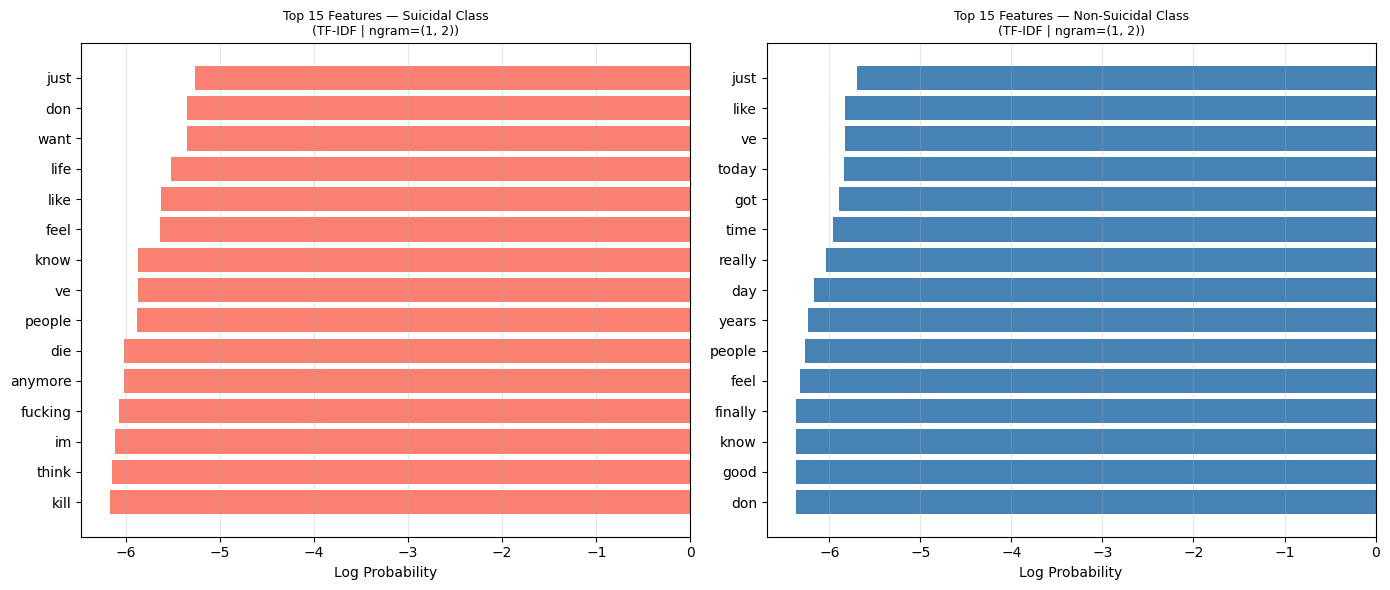

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls_idx, cls_name, color in zip(
    axes, [1, 0], ["Suicidal", "Non-Suicidal"], ["salmon", "steelblue"]
):
    top_idx = np.argsort(log_prob[cls_idx])[-15:][::-1]
    top_names = feature_names[top_idx]
    top_vals = log_prob[cls_idx][top_idx]
    ax.barh(top_names[::-1], top_vals[::-1], color=color)
    ax.set_title(f"Top 15 Features — {cls_name} Class\n({best_name})", fontsize=9)
    ax.set_xlabel("Log Probability")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### **Error Analysis Discussion**

From the misclassification examples, false negatives often appear when suicidal intent is expressed indirectly, ambiguously, or with neutral wording, which reduces the model’s confidence for the Suicidal class. False positives, in contrast, tend to contain emotionally intense language that overlaps with suicidal vocabulary but lacks direct self-harm intent. This shows that lexical overlap alone can blur the boundary between distress and suicidality.

The top discriminating features confirm that the model relies heavily on high-frequency class-associated tokens and phrases. This supports strong overall performance, but it also explains errors in nuanced posts where context, sarcasm, or implied meaning is more important than explicit wording. Overall, the best model is reliable, but remaining errors suggest that future improvement should target context-sensitive signals to further reduce critical false negatives.

### **Final Summary**

A concise summary of all four model configurations and their final test performance. All configurations are effective, but **TF-IDF with ngram=(1,2)** provides the best overall balance of F1 performance and error trade-off, making it the recommended final model.




In [27]:
print("FINAL SUMMARY | MultinomialNB Model")
print(f"\n{'Model':<40} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 63)
for name, res in results.items():
    marker = "  ← BEST" if name == best_name else ""
    print(
        f"{name:<40} "
        f"{res['f1']:>6.4f} "
        f"{res['fn']:>5} "
        f"{res['fp']:>5}"
        f"{marker}"
    )
 
print(f"\nBest Configuration  : {best_name}")
print(f"Best Alpha          : {best_alphas[best_name]}")
print(f"Test F1 (Suicidal)  : {best_res['f1']:.4f}")
print(f"False Negatives     : {best_res['fn']} ({best_res['fn']/y_test.sum():.2%} of suicidal posts missed)")
print(f"False Positives     : {best_res['fp']} ({best_res['fp']/(y_test==0).sum():.2%} of non-suicidal flagged)")

FINAL SUMMARY | MultinomialNB Model

Model                                        F1    FN    FP
---------------------------------------------------------------
TF-IDF | ngram=(1, 1)                    0.9306    60   148
TF-IDF | ngram=(1, 2)                    0.9450    72    89  ← BEST
Count | ngram=(1, 1)                     0.9278    61   156
Count | ngram=(1, 2)                     0.9375    67   118

Best Configuration  : TF-IDF | ngram=(1, 2)
Best Alpha          : 0.5
Test F1 (Suicidal)  : 0.9450
False Negatives     : 72 (4.95% of suicidal posts missed)
False Positives     : 89 (5.42% of non-suicidal flagged)
